In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

## **1. Escoge un conjunto de datos de tu interés**

In [97]:
#Traer la base de datos
from google.colab import files
uploated = files.upload()

Saving Gene Expression Analysis and Disease Relationship.csv to Gene Expression Analysis and Disease Relationship (1).csv


In [98]:
df = pd.read_csv('Gene Expression Analysis and Disease Relationship.csv')

In [99]:
df.head()

,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
0,1,45,0,5.78,3.21,1,1,1
1,2,62,1,7.12,5.89,2,2,0
2,3,38,0,3.15,1.98,0,0,2
3,4,55,1,6.54,4.76,1,1,1
4,5,71,0,8.01,6.55,2,2,0


In [100]:
df.describe(include = "all")

,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.631000,0.50000,3.92314,3.62837,0.058000,0.058000,1.942000
std,288.819436,17.608774,0.50025,2.00056,1.94636,0.307784,0.307784,0.307784
min,1.000000,20.000000,0.00000,0.51000,0.30000,0.000000,0.000000,0.000000
25%,250.750000,34.000000,0.00000,2.19750,1.95000,0.000000,0.000000,2.000000
50%,500.500000,49.000000,0.50000,3.88500,3.58500,0.000000,0.000000,2.000000
75%,750.250000,65.000000,1.00000,5.61250,5.33000,0.000000,0.000000,2.000000
max,1000.000000,80.000000,1.00000,9.01000,7.55000,2.000000,2.000000,2.000000


In [101]:
df["Gene_X_Expression"].value_counts()

,count
Gene_X_Expression,
7.01,5
6.99,5
6.77,4
6.89,4
5.01,4
...,...
7.20,1
7.09,1
6.98,1


////////////// Verificar calidad de los datos

In [102]:
# identificar si datos que se repiten
df["PatientID"].duplicated().sum()

np.int64(0)

In [103]:
df.isnull().sum() #Identificar datos nulos

,0
PatientID,0
Age,0
Gender,0
Gene_X_Expression,0
Gene_Y_Expression,0
SmokingStatus,0
DiseaseStatus,0
TreatmentResponse,0


////////////Comprobar valores correctos segun la describcion del dataset

In [104]:
df["TreatmentResponse"].unique()

array([1, 0, 2])

In [105]:
df["SmokingStatus"].unique()

array([1, 2, 0])

In [106]:
df["DiseaseStatus"].unique()

array([1, 2, 0])

In [107]:
df["Gender"].unique()

array([0, 1])

////////////////////////////////

////////////////////Identificar tendencias (Se evidencia polarizacion de resultados y eso explica los percentiles en el describe)

In [108]:
valor_a_contar = 2
conteo_1 = df['TreatmentResponse'].value_counts().get(valor_a_contar, 0)
print(conteo_1)

962


In [109]:
valor_a_contar = 0
conteo_2 = df['DiseaseStatus'].value_counts().get(valor_a_contar, 0)
print(conteo_2)

962


In [110]:
valor_a_contar = 0
conteo_3 = df['SmokingStatus'].value_counts().get(valor_a_contar, 0)
print(conteo_2)

962


///////////////////

## **2. Utilizando Pandas**

- Exploración de datos nulos, datos duplicados, cantidad de filas y
columnas.

In [111]:
df.duplicated().sum() # Identificar datos duplicados

np.int64(0)

In [112]:
df.info() # Identificar cantidad de filas y columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          1000 non-null   int64  
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   int64  
 3   Gene_X_Expression  1000 non-null   float64
 4   Gene_Y_Expression  1000 non-null   float64
 5   SmokingStatus      1000 non-null   int64  
 6   DiseaseStatus      1000 non-null   int64  
 7   TreatmentResponse  1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


- Limpieza de datos (Pandas: dropna, fillna, replace, etc.)

In [113]:
df1 = df.copy()

In [114]:
# Cambiar formato a la columna Gender
df1["Gender"] = (df1["Gender"]).astype(str)
df1["Gender"] = df1["Gender"].replace({"0": "Female", "1": "Male"})

# Cambiar formato a la columna SmokingStatus
df1["SmokingStatus"] = (df1["SmokingStatus"]).astype(str)
df1["SmokingStatus"] = df1["SmokingStatus"].replace({"0": "No fumador", "1": "Ex fumador", "2": "Fumador"})


# Cambiar formato a la columna TreatmentResponse
df1["TreatmentResponse"] = (df1["TreatmentResponse"]).astype(str)
df1["TreatmentResponse"] = df1["TreatmentResponse"].replace({"0": "No responde", "1": "Responde parcialmente", "2": "Responde completamente"})


# Cambiar formato a la columna DiseaseStatus
df1["DiseaseStatus"] = (df1["DiseaseStatus"]).astype(str)
df1["DiseaseStatus"] = df1["DiseaseStatus"].replace({"0": "Saludable", "1": "Enfermedad A", "2": "Enfermedad B"})


In [115]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          1000 non-null   int64  
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   object 
 3   Gene_X_Expression  1000 non-null   float64
 4   Gene_Y_Expression  1000 non-null   float64
 5   SmokingStatus      1000 non-null   object 
 6   DiseaseStatus      1000 non-null   object 
 7   TreatmentResponse  1000 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


-- Revisar posibles valores atípicos (outliers)

In [116]:
df1 = df1[df1["Age"]<100]

- Filtrado y selección de datos relevantes para tu análisis

In [117]:
df1.head()

,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
0,1,45,Female,5.78,3.21,Ex fumador,Enfermedad A,Responde parcialmente
1,2,62,Male,7.12,5.89,Fumador,Enfermedad B,No responde
2,3,38,Female,3.15,1.98,No fumador,Saludable,Responde completamente
3,4,55,Male,6.54,4.76,Ex fumador,Enfermedad A,Responde parcialmente
4,5,71,Female,8.01,6.55,Fumador,Enfermedad B,No responde


In [118]:
#Conteo de categoria de respuesta al tratamiento
connteo_respuesta = df1.groupby(['TreatmentResponse']).size().reset_index(name='cantidad')
print(connteo_respuesta)

        TreatmentResponse  cantidad
0             No responde        20
1  Responde completamente       962
2   Responde parcialmente        18


In [119]:
# Nuevo dataframe de Promedio de expresion del gen x por genero
from pandas.core.frame import DataFrame
genxporgenero = df1.groupby(["Gender"])["Gene_X_Expression"].mean().reset_index()
print(genxporgenero)

   Gender  Gene_X_Expression
0  Female            3.97594
1    Male            3.87034


In [120]:
# Nuevo dataframe de Promedio de expresion del gen x por edad
from pandas.core.frame import DataFrame
genxporedad = df1.groupby(["Age"])["Gene_X_Expression"].mean().reset_index()
genxporedad.head(60) #Verificar que esten ordenados

,Age,Gene_X_Expression
0,20,0.575625
1,21,0.685625
2,22,0.795625
3,23,0.905625
4,24,1.060000
5,25,1.164706
6,26,1.275882
7,27,1.385294
8,28,1.501765
9,29,1.682222


In [121]:
from pandas.core.frame import DataFrame
genyporedad = df1.groupby(["Age"])["Gene_Y_Expression"].mean().reset_index()
genyporedad.head(60) #Verificar que esten ordenados

,Age,Gene_Y_Expression
0,20,0.363750
1,21,0.473750
2,22,0.583750
3,23,0.693750
4,24,0.795294
5,25,0.905294
6,26,1.015294
7,27,1.119412
8,28,1.230588
9,29,1.346111


In [122]:
Nuevodf = genyporedad.merge(genxporedad, on="Age")
print(Nuevodf)

    Age  Gene_Y_Expression  Gene_X_Expression
0    20           0.363750           0.575625
1    21           0.473750           0.685625
2    22           0.583750           0.795625
3    23           0.693750           0.905625
4    24           0.795294           1.060000
..  ...                ...                ...
56   76           6.525000           6.815000
57   77           6.629375           6.925000
58   78           6.739375           7.035000
59   79           6.849375           7.145000
60   80           6.959375           7.249375

[61 rows x 3 columns]


In [123]:
#Conteo de categorias de fumadores segun genero
connteo = df1.groupby(['Gender', 'SmokingStatus']).size().reset_index(name='cantidad')
print(connteo)

   Gender SmokingStatus  cantidad
0  Female    Ex fumador         9
1  Female       Fumador        15
2  Female    No fumador       476
3    Male    Ex fumador         9
4    Male       Fumador         5
5    Male    No fumador       486


## **3. Formula al menos 5 preguntas de análisis sobre tu conjunto de datos.**

- ¿Cuál es el promedio de expresión del gen x según el género?

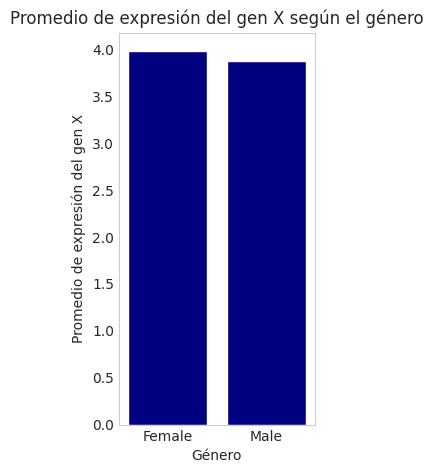

In [124]:
plt.figure(figsize=(2,4))
plt.bar(genxporgenero["Gender"], genxporgenero["Gene_X_Expression"], color =  "navy")
plt.title("Promedio de expresión del gen X según el género")
plt.xlabel("Género")
plt.ylabel("Promedio de expresión del gen X")
plt.show()

**Analisis:** El grafico nos muestra una relacion importante,ya que la expresion del gen en promedio es similiar en ambos generos, lo que indica una relacion no discriminante de dicho gen.

-	¿Cuál es la relación entre la expresión del gen y, y el gen x?

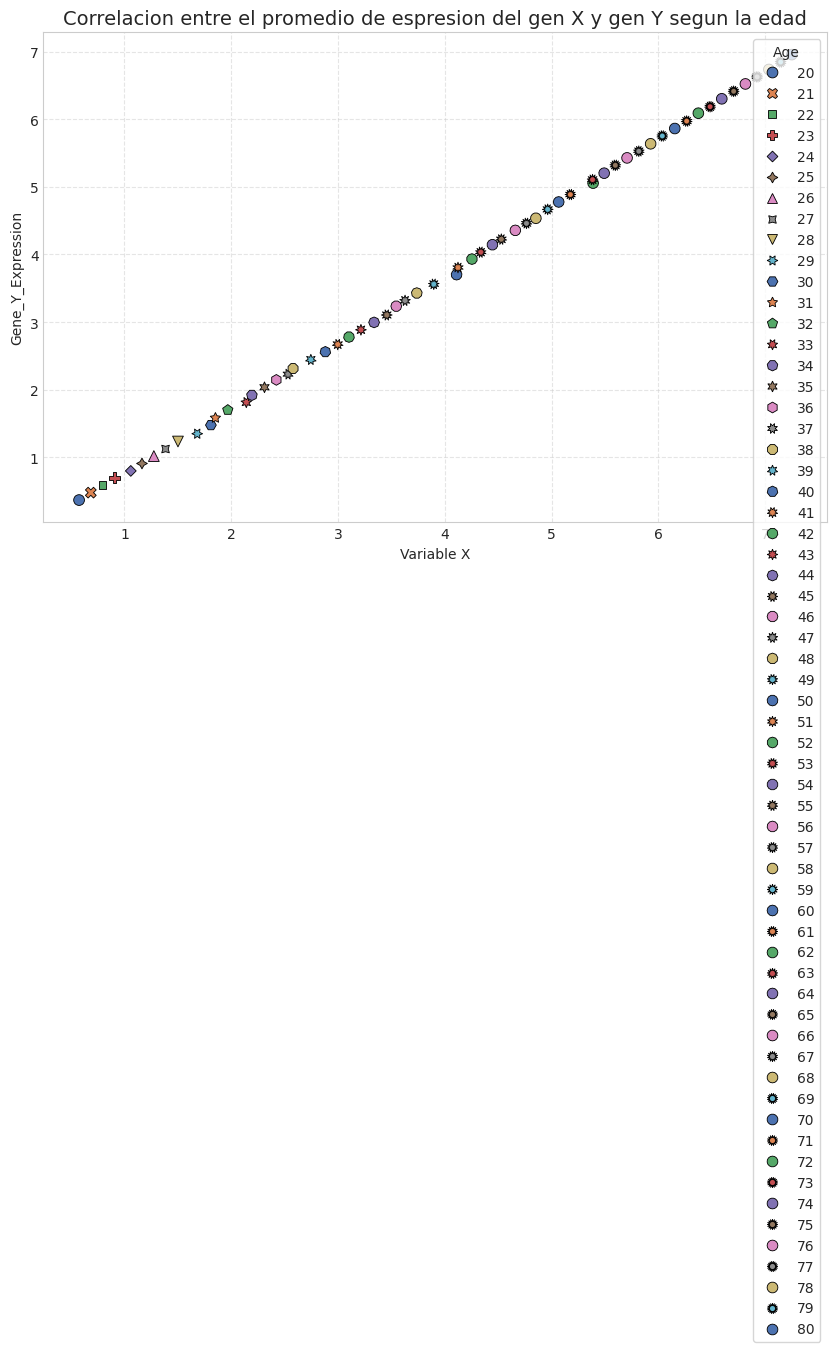

In [130]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=Nuevodf, x="Gene_X_Expression", y="Gene_Y_Expression",
    hue="Age",       # Colores por categoría
    style="Age",     # Diferentes marcadores por categoría
    palette="deep",        # Paleta de colores
    s=60,                 # Tamaño de los puntos
    edgecolor="black"      # Borde de los puntos
)

# Personalizar el gráfico
plt.title("Correlacion entre el promedio de espresion del gen X y gen Y segun la edad", fontsize=14)
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar el gráfico
plt.show()

**Analisis** La relacion entre los promedios de expresion de los genes segun la edad (aunque visualmente es dificil de relacionar), es directamente proporcional lo cual es un indicador impportante paraa encontrar las causas de este fenomeno, como las condiciones ambientales que afectan la expresion genica y el envejecimiento

- ¿Hay alguna relacion entre la categoria de fumador y el genero?

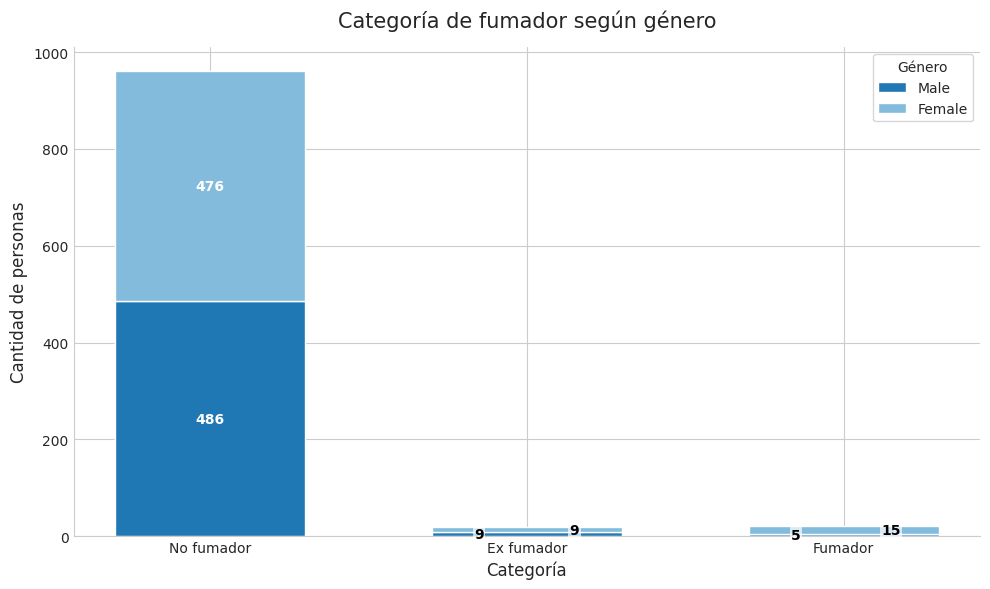

In [136]:
# numero por categoria de fumadores segun genero
categoria_fumador = ('No fumador', 'Ex fumador', 'Fumador')
sex_counts = {
    'Male': np.array([486, 9, 5]),
    'Female': np.array([476, 9, 15]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence



fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(categoria_fumador))
width = 0.6

# Definimos cuánto moveremos los textos pequeños en el eje X
# El primer valor (índice 0) se moverá a la izquierda (-0.15)
# El segundo valor (índice 1) se moverá a la derecha (+0.15)
desplazamiento_x = [-0.15, 0.15]

for i, (sex, sex_count) in enumerate(sex_counts.items()):
    p = ax.bar(categoria_fumador, sex_count, width, label=sex, bottom=bottom)

    # Recorremos cada barra individualmente para colocar su texto
    for j, barra in enumerate(p):
        altura = barra.get_height()

        # Opcional: Si el valor es 0, no lo imprimimos para limpiar el gráfico
        if altura == 0:
            continue

        # Calculamos el centro exacto de la barra actual
        x_centro = barra.get_x() + barra.get_width() / 2
        y_centro = barra.get_y() + altura / 2

        # REGLA: Si el valor es menor a 50 (barra muy pequeña)
        if altura < 50:
            # Le sumamos el desplazamiento correspondiente (izq o der)
            nuevo_x = x_centro + desplazamiento_x[i]

            ax.text(nuevo_x, y_centro, str(int(altura)),
                    ha='center', va='center', color='black', fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)) # Fondo blanco para que se lea mejor

        # REGLA: Si la barra es lo suficientemente grande
        else:
            # Lo dejamos exactamente en el centro
            ax.text(x_centro, y_centro, str(int(altura)),
                    ha='center', va='center', color='white', fontweight='bold')

    bottom += sex_count

ax.set_title('Categoría de fumador según género', fontsize=15, pad=15)
ax.set_ylabel('Cantidad de personas', fontsize=12)
ax.set_xlabel('Categoría', fontsize=12)

ax.legend(title='Género', loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

**Analisis:** Como es visible los valores mas grandes son los que pertenecen a la catefgoria de no fumador y es aproximadamente igual en ambos generos, mientras en la categoria de exfumador son exactamente iguales, pero en la categoria fumador hay mas peronas fumadoras en el genero femenino que masculino, lo cual indica una relacion importante de analisis posterior para evidenciar si existe correlacion con el genero y ser fumador activo, y la presencia de alguna enfermedad

In [127]:
connteo_respuesta

,TreatmentResponse,cantidad
0,No responde,20
1,Responde completamente,962
2,Responde parcialmente,18


¿Como se ve la distribuccion de los pacientes segun su respuesta al tratamiento?

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


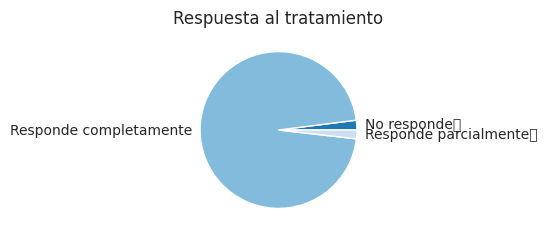

In [140]:


valores = [20, 962, 18]
etiquetas = ["No responde	","Responde completamente","Responde parcialmente	"]
fig, ax = plt.subplots()
plt.pie(valores, labels=etiquetas, pctdistance=2.0)
plt.title("Respuesta al tratamiento")
plt.show()


**Analisis:** Como se puede observar hay un alto porcentaje d e personas que responden al tratamiento y ya que hemos visto en graficas anteriores, hay un patron de personas con buenos habitos, que nos permite sugerir la hipotesis de que esto podria estar influyendo en los resultados que se muestran. Por otro lafo la cantidad de pacientes que no respondieron y que respondieron parcialmente es casi igual, pero sus cvalores son demasiados pequeños.

- ¿Hay valores atipicos en la columna de edad?

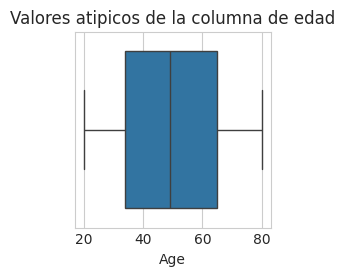

In [139]:
sns.boxplot(x=df1["Age"])
plt.title("Valores atipicos de la columna de edad")
plt.show()

**Analisis:** Debido a que no hay valores que salgan fuera de los "bigotes" del grafico se puede determinar que no existen  valores que se alejen de el conjunto de datos por lo tanto no hya valores atipicos en la columna edad